# Praktikum Machine Learning: Bab 4
## Feature Engineering: Konstruksi, Seleksi Fitur, dan Pipeline Scikit-Learn

| | |
|---|---|
| **Nama** | Ahmad Dandi Subhani |
| **NPM** | 202343500126 |
| **Kelas** | R7B |
| **Mata Kuliah** | Machine Learning |
| **Dosen** | Nurfidah Dwitiyanti, M.Si. |

*Notebook ini saya jalanin di Google Colab / Jupyter Notebook.*

## Ringkasan Konsep

**Feature construction (konstruksi fitur)** itu bikin fitur *baru* dari fitur mentah biar pola yang susah dilihat model jadi keliatan jelas. Contohnya rasio (`AveBedrms / AveRooms`), interaksi antar fitur, atau *binning* (ngubah numerik jadi kategorikal, misal bikin "wilayah" dari garis lintang). Bedanya sama *feature extraction* (mis. PCA): hasil konstruksi fitur tetep bisa dibaca manusia, kalau PCA enggak, namanya aja ilang.

**Feature selection (seleksi fitur)**: milih subset fitur yang paling relevan. Ada tiga pendekatan:

1. **Filter**: tiap fitur dinilai pake skor statistik *tanpa* libatin model. Contoh `SelectKBest` pake skor chi-square. Cepet, tapi interaksi antar fitur diabaikan.
2. **Wrapper**: subset fitur dievaluasi dengan ngelatih model beneran. Contoh **RFE** (*Recursive Feature Elimination*), yang buang fitur terlemah satu per satu. Lebih akurat, tapi mahal secara komputasi.
3. **Embedded**: seleksi terjadi *selama* pelatihan lewat regularisasi. Contoh **Lasso/L1** yang maksa koefisien fitur gak penting jadi nol. Jalan tengah antara filter yang cepet dan wrapper yang akurat.

**ColumnTransformer** nerapin transformasi *beda-beda* ke kelompok kolom yang beda dalam satu langkah. Misal `StandardScaler` buat kolom numerik, `OneHotEncoder` buat kategorikal nominal, `OrdinalEncoder` buat kategorikal ordinal. Semuanya jalan sekaligus di satu DataFrame campuran.

**Pipeline** ngerangkai preprocessing + model jadi **satu objek**. Untungnya: `pipeline.fit(X_train)` cuma belajar statistik (mean, median, kategori) dari data latih, terus `pipeline.predict(data_baru)` otomatis nerapin preprocessing yang *persis sama*. Jadi gak ada risiko preprocessing pas training beda sama pas deployment.

**Data leakage** itu "kebocoran" info data uji ke proses training. Contohnya nge-*fit* scaler/imputer ke *seluruh* data *sebelum* train-test split. Akibatnya statistik data uji ikut kepake buat ngelatih model, skor evaluasi keliatan bagus padahal palsu. Pipeline mencegah ini karena tiap transformasi cuma di-fit di data latih.

In [1]:
# Sel 0 - Persiapan awal (jalan otomatis paling awal saat Run All).
# Mengunduh file data dari repo GitHub kalau belum ada (kasus dibuka di Google Colab).
# Di laptop (folder data/ sudah ada), bagian unduh langsung dilewati.
import os
import urllib.request

_BAB = "bab-04-feature-engineering-pipeline"  # nama folder bab ini di repo GitHub
_REPO = "https://raw.githubusercontent.com/dandienter/praktikumML/main"
_DATA = ['data/titanic.csv', 'data/breast_cancer.csv']  # file data yang dibutuhkan bab ini

for _f in _DATA:
    if os.path.exists(_f):
        print(f"OK: {_f} sudah ada.")
        continue
    os.makedirs(os.path.dirname(_f), exist_ok=True)
    print(f"mengunduh {_f} dari GitHub ...")
    urllib.request.urlretrieve(f"{_REPO}/{_BAB}/{_f}", _f)

# Library umum yang dipakai di Latihan Praktikum
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print("Paket siap.")


OK: data/titanic.csv sudah ada.
OK: data/breast_cancer.csv sudah ada.


Paket siap.


## 4.16 Latihan Praktikum (Modul Bab 4)

Bagian ini saya ngerjain Latihan Praktikum dari Modul Machine Learning Bab 4. Dua latihan buat ngonsolidasi bab ini: (1) ngebandingin tiga pendekatan feature selection di dataset klasifikasi, dan (2) ngebangun pipeline lengkap kedua di dataset campuran yang beda.

### Praktikum 1 (4.3) - Membandingkan Tiga Pendekatan Feature Selection (Modul Bab 4)

Dataset **Breast Cancer** (569 sampel, 30 fitur numerik. Semuanya non-negatif jadi skor chi-square valid). Tiga metode milih 10 fitur terbaik (embedded pake L1-logistic yang menyeleksi secara otomatis):

- **Filter:** `SelectKBest(chi2, k=10)`: skor statistik murni, tanpa model.
- **Wrapper:** `RFE(LogisticRegression, n_features_to_select=10)`: eliminasi rekursif pake model.
- **Embedded:** `SelectFromModel(LogisticRegression(l1_ratio=1, C=0.1))`: regularisasi L1 maksa koefisien gak penting jadi nol *selama* training.

In [2]:
# Import tambahan untuk latihan feature selection
from sklearn.feature_selection import SelectKBest, chi2, RFE, SelectFromModel
from sklearn.linear_model import LogisticRegression

# Dataset Breast Cancer dibaca dari file CSV lokal (data/breast_cancer.csv)
df_bc = pd.read_csv('data/breast_cancer.csv')
fitur_bc = [c for c in df_bc.columns if c not in ('target', 'target_name')]
X_bc, y_bc = df_bc[fitur_bc].values, df_bc['target'].values
nama_fitur = np.array(fitur_bc)

# 1) Filter
skb = SelectKBest(chi2, k=10).fit(X_bc, y_bc)
f_filter = set(np.argsort(skb.scores_)[-10:])

# 2) Wrapper
rfe = RFE(LogisticRegression(max_iter=5000), n_features_to_select=10).fit(X_bc, y_bc)
f_wrapper = set(rfe.get_support(indices=True))

# 3) Embedded (L1)
l1 = SelectFromModel(
    LogisticRegression(l1_ratio=1, solver='saga', C=0.1, max_iter=10000,
                       random_state=42)
).fit(X_bc, y_bc)
f_embedded = set(l1.get_support(indices=True))

semua = sorted(f_filter | f_wrapper | f_embedded)
tabel = pd.DataFrame({
    'fitur': [nama_fitur[i] for i in semua],
    'filter (chi2)': ['ya' if i in f_filter else '-' for i in semua],
    'wrapper (RFE)': ['ya' if i in f_wrapper else '-' for i in semua],
    'embedded (L1)': ['ya' if i in f_embedded else '-' for i in semua],
})
print(tabel.to_string(index=False))
print(f"\nJumlah fitur terpilih: filter={len(f_filter)}, "
      f"wrapper={len(f_wrapper)}, embedded={len(f_embedded)}")
print(f"Irisan ketiga metode (dipilih semua): "
      f"{[nama_fitur[i] for i in sorted(f_filter & f_wrapper & f_embedded)]}")

               fitur filter (chi2) wrapper (RFE) embedded (L1)
         mean radius            ya            ya            ya
        mean texture            ya             -            ya
      mean perimeter            ya             -            ya
           mean area            ya             -            ya
    mean compactness             -            ya             -
      mean concavity             -            ya             -
       texture error             -            ya             -
     perimeter error            ya             -             -
          area error            ya             -            ya
        worst radius            ya            ya            ya
       worst texture            ya             -            ya
     worst perimeter            ya             -            ya
          worst area            ya             -            ya
    worst smoothness             -            ya             -
   worst compactness             -            ya       

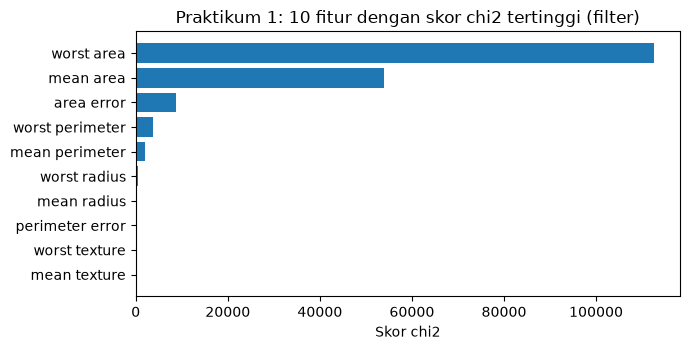

In [3]:
# Grafik Praktikum 1: skor chi2 untuk 10 fitur teratas (metode filter)
skor = skb.scores_
top10 = np.argsort(skor)[-10:][::-1]
plt.figure(figsize=(7, 3.6))
plt.barh([nama_fitur[i] for i in top10], skor[top10])
plt.xlabel("Skor chi2")
plt.title("Praktikum 1: 10 fitur dengan skor chi2 tertinggi (filter)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Penjelasan grafiknya:** metode filter menilai tiap fitur secara individual lewat skor chi2. Fitur-fitur `worst ...` (nilai terburuk tiap pengukuran sel) mendominasi peringkat teratas, masuk akal karena sel kanker ganas cenderung punya nilai ekstrem. Kelemahan filter yang terlihat di sini: fitur terpilih saling berkorelasi (banyak varian pengukuran yang sama), sedangkan wrapper/embedded memilih kombinasi yang saling melengkapi di dalam model.

**Penjelasan outputnya:**

1. Ketiga metode **gak milih himpunan yang identik**. Dari 18 fitur yang dipilih minimal satu metode, cuma **2** yang disepakati ketiganya: `mean radius` dan `worst radius`. Ini wajar: filter menilai tiap fitur *sendiri-sendiri* jadi cenderung milih fitur-fitur yang saling berkorelasi (banyak varian "worst ..." dan "mean ..."), sedangkan wrapper dan embedded mempertimbangkan **kontribusi fitur dalam konteks model**. RFE malah banyak milih fitur "*... error*" dan "*worst ...*" yang saling melengkapi di dalam model.
2. **Filter (chi2)** tercepat: cuma ngitung statistik sekali. **Wrapper (RFE)** paling lambat: ngelatih LogisticRegression berulang kali sambil buang fitur terlemah. **Embedded (L1)** cuma butuh satu kali training dan otomatis nentuin jumlah fitur (di sini 9 fitur, bukan genap 10).
3. **Kesimpulan:** gak ada metode yang "selalu bener". Filter cocok buat penyaringan awal yang cepet di data berdimensi besar; wrapper buat akurasi maksimal kalo komputasi bukan masalah; embedded sebagai jalan tengah yang elegan: seleksi terjadi sebagai efek samping training. Di praktiknya ketiganya sering **dikombinasikan** (filter dulu buat buang yang jelas-jelas noise, terus wrapper/embedded).

### Praktikum 2 - Membangun Pipeline Lengkap (Dataset Titanic) (Modul Bab 4)

Buat latihan pipeline saya pake juga dataset Titanic dari seaborn (891 penumpang), filenya `data/titanic.csv`. Ini contoh klasik data campuran: numerik (`age`, `fare`, `sibsp`, `parch`) + kategorikal (`sex`, `embarked`, `class`) dengan target klasifikasi `survived`. Pipeline: `ColumnTransformer` (numerik jadi median + scaler; kategorikal jadi most_frequent + one-hot) + `LogisticRegression`, dievaluasi pake **akurasi** di data uji.

In [4]:
# Import tambahan untuk latihan pipeline Titanic
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Dataset Titanic dibaca dari file CSV lokal (data/titanic.csv) - bisa dipakai offline
df_t = pd.read_csv('data/titanic.csv')
print("Dataset Titanic berhasil dimuat:", df_t.shape)
fitur_num_t = ['age', 'fare', 'sibsp', 'parch']
fitur_cat_t = ['sex', 'embarked', 'class']
X_t = df_t[fitur_num_t + fitur_cat_t]
y_t = df_t['survived']

print("\nMissing value per kolom:", X_t.isna().sum().to_dict())

Xtr, Xte, ytr, yte = train_test_split(X_t, y_t, test_size=0.2, random_state=42)

pipe_titanic = Pipeline(steps=[
    ('preprocessing', ColumnTransformer([
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')),
                          ('scaler', StandardScaler())]), fitur_num_t),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                          ('onehot', OneHotEncoder(
                              handle_unknown='ignore'))]), fitur_cat_t),
    ])),
    ('model', LogisticRegression(max_iter=1000)),
])
pipe_titanic.fit(Xtr, ytr)
akurasi = accuracy_score(yte, pipe_titanic.predict(Xte))
print(f"\nAkurasi pada data uji: {akurasi:.4f}")
print("Prediksi 1 penumpang baru:", pipe_titanic.predict(Xte.iloc[[0]])[0],
      "(aktual:", yte.iloc[0], ")")

Dataset Titanic berhasil dimuat: (891, 15)

Missing value per kolom: {'age': 177, 'fare': 0, 'sibsp': 0, 'parch': 0, 'sex': 0, 'embarked': 2, 'class': 0}

Akurasi pada data uji: 0.7989
Prediksi 1 penumpang baru: 0 (aktual: 1 )


<Figure size 420x360 with 0 Axes>

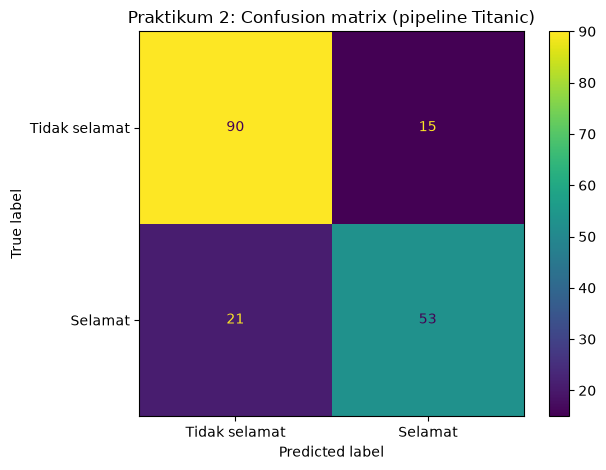

In [5]:
# Grafik Praktikum 2: confusion matrix pipeline Titanic di data uji
from sklearn.metrics import ConfusionMatrixDisplay
plt.figure(figsize=(4.2, 3.6))
ConfusionMatrixDisplay.from_estimator(pipe_titanic, Xte, yte,
                                      display_labels=["Tidak selamat", "Selamat"])
plt.title("Praktikum 2: Confusion matrix (pipeline Titanic)")
plt.tight_layout()
plt.show()

**Penjelasan grafiknya:** confusion matrix menunjukkan di mana model paling sering salah. Pola umumnya: model cukup baik mengenali penumpang yang tidak selamat, tapi sebagian penumpang yang selamat diprediksi tidak selamat. Ini wajar untuk model linear sederhana tanpa feature engineering lanjutan, dan alasannya akurasi 0,80 bukan 1,00.

**Penjelasan outputnya:**

1. Dataset Titanic berhasil dimuat (891 baris, 15 kolom) dari file lokal `data/titanic.csv`.
2. Missing value kedeteksi di `age` (sekitar 177) dan `embarked` (2). Keduanya ditangani otomatis di dalam pipeline (median buat numerik, modus buat kategorikal), tanpa satu baris pun kode pembersihan manual di luar pipeline.
3. Akurasi **0,7989** di data uji: wajar buat model linear sederhana tanpa *feature engineering* lanjutan, dan konsisten sama benchmark umum dataset Titanic.
4. Prediksi satu baris data mentah langsung jalan tanpa preprocessing manual. Sekali lagi nunjukin keunggulan pipeline: data baru cukup dilempar ke `pipe.predict()`, preprocessing yang tepat (termasuk penanganan NaN dan kategori gak dikenal via `handle_unknown='ignore'`) udah "terkunci" di dalamnya. Catatan jujur: prediksi contoh baris itu 0 padahal aktualnya 1. Pengingat kalo akurasi 80% artinya sekitar 1 dari 5 prediksi meleset.

## Kesimpulan Bab 4

1. **Feature selection (Praktikum 1):** tiga pendekatan milih himpunan fitur yang **beda-beda** di dataset Breast Cancer. Dari 18 fitur yang dipilih minimal satu metode, cuma 2 yang disepakati ketiganya (`mean radius` dan `worst radius`). Filter (chi2) tercepat karena cuma ngitung statistik; wrapper (RFE) paling mahal karena ngelatih model berulang kali; embedded (L1) jalan tengah yang elegan karena seleksi terjadi sebagai efek samping training. Gak ada metode yang selalu terbaik, ketiganya sering dikombinasikan.
2. **Pipeline (Praktikum 2):** `ColumnTransformer` + `Pipeline` nangani data campuran Titanic (numerik + kategorikal) dalam satu objek dan mencapai akurasi **0,7989** di data uji. Missing value di `age` dan `embarked` ditangani otomatis di dalam pipeline, tanpa kode pembersihan manual.
3. **Keuntungan terbesar pipeline** keliatan pas deployment: `pipe.predict(data_mentah)` selalu nerapin preprocessing yang identik sama training, termasuk kategori gak dikenal (`handle_unknown='ignore'`). Jadi gak ada risiko preprocessing pas training beda sama pas prediksi.
4. **Confusion matrix** nunjukin model paling sering salah di penumpang yang selamat tapi diprediksi tidak selamat. Wajar buat model linear sederhana tanpa feature engineering lanjutan, dan pengingat kalo akurasi 80% artinya sekitar 1 dari 5 prediksi meleset.